#### DSC 680 Project 3 Milestone 3/Final: NBA Team Success Analysis

**William Anderson**  
**DSC 680: Applied Data Science**  



#### import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

#### set file path

The file path below points to the archive folder where the NBA team datasets are saved. This should work as long as the two CSV files stay in the same folder.

In [2]:
DATA_DIR = Path(r"C:\BU MS DS\DSC680 - Applied Data Science\archive")

regular_season_file = DATA_DIR / "nba_team_stats_00_to_23.csv"
playoff_file = DATA_DIR / "nba_team_stats_playoffs_00_to_21.csv"

output_dir = DATA_DIR / "project3_milestone2_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Regular-season file:", regular_season_file)
print("Playoff file:", playoff_file)
print("Output folder:", output_dir)

Regular-season file: C:\BU MS DS\DSC680 - Applied Data Science\archive\nba_team_stats_00_to_23.csv
Playoff file: C:\BU MS DS\DSC680 - Applied Data Science\archive\nba_team_stats_playoffs_00_to_21.csv
Output folder: C:\BU MS DS\DSC680 - Applied Data Science\archive\project3_milestone2_outputs


#### load the regular-season dataset

For this milestone, the regular-season dataset is the main dataset. The playoff file may be useful later as a supporting file, but the main model below focuses on regular-season team success.

In [23]:
teams = pd.read_csv(regular_season_file)

print("Shape:", teams.shape)
display(teams.head())

Shape: (716, 29)


,teamstatspk,Team,games_played,wins,losses,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,offensive_rebounds,defensive_rebounds,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,876,2923,3799,2207,979,557,538,304,1326,1416,930,2023-24
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,881,2762,3643,2415,1036,585,456,394,1489,1467,431,2023-24
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,722,2725,3447,2223,1039,694,538,419,1545,1548,608,2023-24
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,770,2807,3577,2184,1162,647,497,371,1544,1630,529,2023-24
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,822,2701,3523,2097,1078,640,413,384,1519,1537,269,2023-24


#### review columns and basic structure

Before doing anything else, I want to see the columns, data types, and a few basic summary statistics. This helps confirm that the dataset loaded correctly and that the main fields are available.

In [24]:
print("Cols:")
print(teams.columns.tolist())

display(teams.info())
display(teams.describe(include="all").T)

Cols:
['teamstatspk', 'Team', 'games_played', 'wins', 'losses', 'win_percentage', 'Min', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 'free_throw_percentage', 'offensive_rebounds', 'defensive_rebounds', 'rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'blocks_attempted', 'personal_fouls', 'personal_fouls_drawn', 'plus_minus', 'season']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   teamstatspk               716 non-null    int64  
 1   Team                      716 non-null    object 
 2   games_played              716 non-null    int64  
 3   wins                      716 non-null    int64  
 4   losses                    716 non-null    int64  
 5   win_

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
teamstatspk,716.0,NaN,NaN,NaN,357.5,206.835684,0.0,178.75,357.5,536.25,715.0
Team,716,37,Boston Celtics,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
games_played,716.0,NaN,NaN,NaN,80.430168,4.286506,64.0,82.0,82.0,82.0,82.0
wins,716.0,NaN,NaN,NaN,40.215084,12.215024,7.0,32.0,41.0,49.0,73.0
losses,716.0,NaN,NaN,NaN,40.215084,12.133228,9.0,31.0,39.0,49.0,72.0
win_percentage,716.0,NaN,NaN,NaN,0.499784,0.148919,0.106,0.39,0.512,0.61,0.89
Min,716.0,NaN,NaN,NaN,3888.927374,207.68472,3112.0,3951.0,3961.0,3971.0,4016.0
points,716.0,NaN,NaN,NaN,8230.385475,712.154467,5739.0,7838.5,8182.5,8641.5,10110.0
field_goals_made,716.0,NaN,NaN,NaN,3062.22067,251.252302,2193.0,2931.75,3050.5,3208.5,3855.0
field_goals_attempted,716.0,NaN,NaN,NaN,6716.244413,446.747528,5086.0,6490.75,6724.0,7018.0,7739.0


#### clean column names

The dataset is already pretty readable, but cleaning the column names makes the rest of the notebook easier to write and reduces random naming issues.

In [5]:
teams_clean = teams.copy()

teams_clean.columns = (
    teams_clean.columns
    .str.strip()
    .str.lower()
    .str.replace("%", "pct", regex=False)
    .str.replace("+/-", "plus_minus", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print(teams_clean.columns.tolist())
display(teams_clean.head())

['teamstatspk', 'team', 'games_played', 'wins', 'losses', 'win_percentage', 'min', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 'free_throw_percentage', 'offensive_rebounds', 'defensive_rebounds', 'rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'blocks_attempted', 'personal_fouls', 'personal_fouls_drawn', 'plus_minus', 'season']


,teamstatspk,team,games_played,wins,losses,win_percentage,min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,offensive_rebounds,defensive_rebounds,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,876,2923,3799,2207,979,557,538,304,1326,1416,930,2023-24
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,881,2762,3643,2415,1036,585,456,394,1489,1467,431,2023-24
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,722,2725,3447,2223,1039,694,538,419,1545,1548,608,2023-24
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,770,2807,3577,2184,1162,647,497,371,1544,1630,529,2023-24
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,822,2701,3523,2097,1078,640,413,384,1519,1537,269,2023-24


#### check for missing values

This section checks whether the dataset has missing values. If missing values exist, they would need to be handled before building the model; if not, the analysis can move forward more cleanly.

In [25]:
missing_values = teams_clean.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

No missing values found.


#### create per-game features

A lot of the team statistics are season totals, so I am creating per-game versions of the main counting stats. This is especially useful because not every NBA season in the dataset has the same number of games, and per-game values make comparisons cleaner.

In [26]:
counting_stats = [
    "points",
    "field_goals_made",
    "field_goals_attempted",
    "three_pointers_made",
    "three_pointers_attempted",
    "free_throws_made",
    "free_throw_attempted",
    "offensive_rebounds",
    "defensive_rebounds",
    "rebounds",
    "assists",
    "turnovers",
    "steals",
    "blocks",
    "blocks_attempted",
    "personal_fouls",
    "personal_fouls_drawn",
    "plus_minus"
]

for col in counting_stats:
    if col in teams_clean.columns:
        teams_clean[f"{col}_per_game"] = teams_clean[col] / teams_clean["games_played"]

display(teams_clean.head())

,teamstatspk,team,games_played,wins,losses,win_percentage,min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,offensive_rebounds,defensive_rebounds,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season,points_per_game,field_goals_made_per_game,field_goals_attempted_per_game,three_pointers_made_per_game,three_pointers_attempted_per_game,free_throws_made_per_game,free_throw_attempted_per_game,offensive_rebounds_per_game,defensive_rebounds_per_game,rebounds_per_game,assists_per_game,turnovers_per_game,steals_per_game,blocks_per_game,blocks_attempted_per_game,personal_fouls_per_game,personal_fouls_drawn_per_game,plus_minus_per_game
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,876,2923,3799,2207,979,557,538,304,1326,1416,930,2023-24,120.573171,43.914634,90.195122,16.475610,42.463415,16.268293,20.170732,10.682927,35.646341,46.329268,26.914634,11.939024,6.792683,6.560976,3.707317,16.170732,17.268293,11.341463
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,881,2762,3643,2415,1036,585,456,394,1489,1467,431,2023-24,114.853659,44.024390,88.768293,11.682927,31.219512,15.121951,19.853659,10.743902,33.682927,44.426829,29.451220,12.634146,7.134146,5.560976,4.804878,18.158537,17.890244,5.256098
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,722,2725,3447,2223,1039,694,538,419,1545,1548,608,2023-24,120.085366,44.548780,89.317073,13.292683,34.207317,17.695122,21.451220,8.804878,33.231707,42.036585,27.109756,12.670732,8.463415,6.560976,5.109756,18.841463,18.878049,7.414634
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,770,2807,3577,2184,1162,647,497,371,1544,1630,529,2023-24,112.975610,41.256098,85.048780,12.646341,32.695122,17.817073,22.939024,9.390244,34.231707,43.621951,26.634146,14.170732,7.890244,6.060976,4.524390,18.829268,19.878049,6.451220
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,822,2701,3523,2097,1078,640,413,384,1519,1537,269,2023-24,115.621951,42.353659,86.682927,12.634146,33.158537,18.280488,22.158537,10.024390,32.939024,42.963415,25.573171,13.146341,7.804878,5.036585,4.682927,18.524390,18.743902,3.280488


#### review target variable

Winning percentage is the main target variable for this analysis. Using winning percentage instead of raw wins is cleaner because it is less affected by shortened seasons.

In [28]:
target = "win_percentage"

display(teams_clean[[target, "wins", "losses", "games_played"]].describe())

if "season" in teams_clean.columns:
    display(
        teams_clean
        .groupby("season")[[target, "wins", "losses", "games_played"]]
        .mean()
        .tail()
    )

,win_percentage,wins,losses,games_played
count,716.000000,716.000000,716.000000,716.000000
mean,0.499784,40.215084,40.215084,80.430168
std,0.148919,12.215024,12.133228,4.286506
min,0.106000,7.000000,9.000000,64.000000
25%,0.390000,32.000000,31.000000,82.000000
50%,0.512000,41.000000,39.000000,82.000000
75%,0.610000,49.000000,49.000000,82.000000
max,0.890000,73.000000,72.000000,82.000000


,win_percentage,wins,losses,games_played
season,,,,
2019-20,0.494933,35.3,35.3,70.6
2020-21,0.500033,36.0,36.0,72.0
2021-22,0.499933,41.0,41.0,82.0
2022-23,0.499967,41.0,41.0,82.0
2023-24,0.500000,41.0,41.0,82.0


#### visual 1: distribution of winning percentage

This chart shows how team winning percentage is distributed across the dataset. It gives a quick view of how many team-seasons fall near average and how many are closer to the extremes.

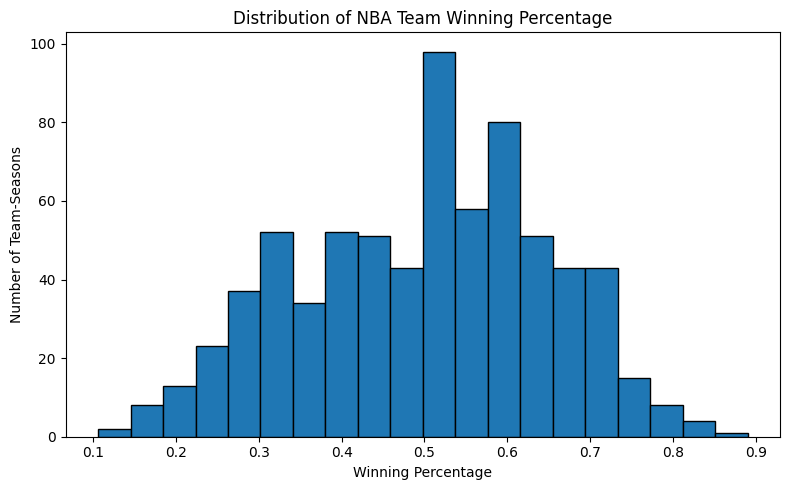

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(teams_clean[target], bins=20, edgecolor="black")
plt.title("Distribution of NBA Team Winning Percentage")
plt.xlabel("Winning Percentage")
plt.ylabel("Number of Team-Seasons")
plt.tight_layout()
plt.savefig(output_dir / "figure1_distribution_of_winning_percentage.png", dpi=300)
plt.show()

#### visual 2: wins by season

This chart looks at average wins by season. Since some seasons are shortened or otherwise different, it is a useful reminder that raw win totals are not always directly comparable.

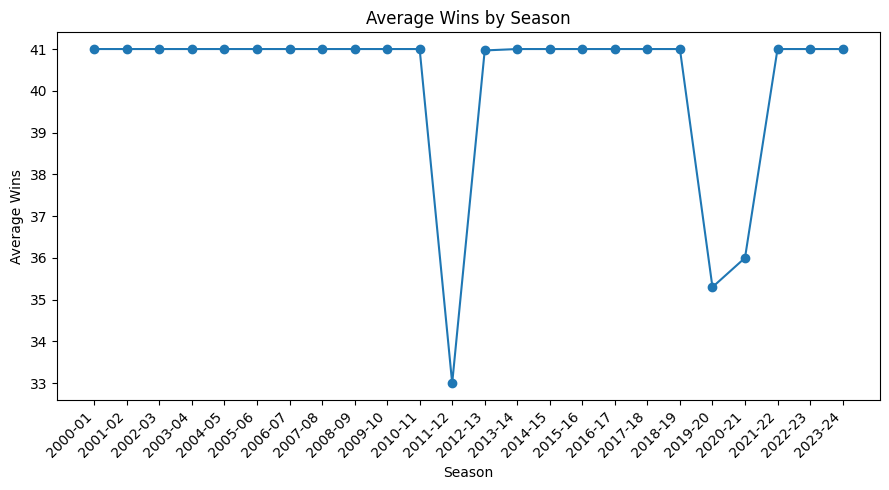

In [30]:
season_summary = (
    teams_clean
    .groupby("season", as_index=False)
    .agg(avg_wins=("wins", "mean"), avg_win_percentage=("win_percentage", "mean"))
)

plt.figure(figsize=(9, 5))
plt.plot(season_summary["season"], season_summary["avg_wins"], marker="o")
plt.title("Average Wins by Season")
plt.xlabel("Season")
plt.ylabel("Average Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "figure2_average_wins_by_season.png", dpi=300)
plt.show()

#### choose modeling features

The model uses efficiency stats and per-game team stats. Wins, losses, raw games played, and identifying columns are left out so the model does not simply reuse the answer or team labels.

In [31]:
feature_cols = [
    "field_goal_percentage",
    "three_point_percentage",
    "free_throw_percentage",
    "points_per_game",
    "field_goals_made_per_game",
    "field_goals_attempted_per_game",
    "three_pointers_made_per_game",
    "three_pointers_attempted_per_game",
    "free_throws_made_per_game",
    "free_throw_attempted_per_game",
    "offensive_rebounds_per_game",
    "defensive_rebounds_per_game",
    "rebounds_per_game",
    "assists_per_game",
    "turnovers_per_game",
    "steals_per_game",
    "blocks_per_game",
    "blocks_attempted_per_game",
    "personal_fouls_per_game",
    "personal_fouls_drawn_per_game",
    "plus_minus_per_game"
]

feature_cols = [col for col in feature_cols if col in teams_clean.columns]

print("Feature count:", len(feature_cols))
print(feature_cols)

Feature count: 21
['field_goal_percentage', 'three_point_percentage', 'free_throw_percentage', 'points_per_game', 'field_goals_made_per_game', 'field_goals_attempted_per_game', 'three_pointers_made_per_game', 'three_pointers_attempted_per_game', 'free_throws_made_per_game', 'free_throw_attempted_per_game', 'offensive_rebounds_per_game', 'defensive_rebounds_per_game', 'rebounds_per_game', 'assists_per_game', 'turnovers_per_game', 'steals_per_game', 'blocks_per_game', 'blocks_attempted_per_game', 'personal_fouls_per_game', 'personal_fouls_drawn_per_game', 'plus_minus_per_game']


#### correlation review

This is a first-pass review of which features are most related to winning percentage. It does not prove causation, but it helps show which team stats may be worth paying attention to.

In [32]:
corr_with_target = (
    teams_clean[feature_cols + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(corr_with_target)

plus_minus_per_game                  0.967645
field_goal_percentage                0.545442
three_point_percentage               0.503812
blocks_attempted_per_game           -0.464440
turnovers_per_game                  -0.362095
defensive_rebounds_per_game          0.316209
points_per_game                      0.277486
assists_per_game                     0.264443
blocks_per_game                      0.251487
field_goals_made_per_game            0.249606
rebounds_per_game                    0.248966
personal_fouls_per_game             -0.209098
three_pointers_made_per_game         0.172190
free_throw_percentage                0.165924
free_throws_made_per_game            0.151699
steals_per_game                      0.147729
offensive_rebounds_per_game         -0.140495
three_pointers_attempted_per_game    0.106072
free_throw_attempted_per_game        0.092164
field_goals_attempted_per_game      -0.058906
personal_fouls_drawn_per_game        0.013283
Name: win_percentage, dtype: float

#### visual 3: strongest correlations with winning percentage

This chart shows the strongest correlations with winning percentage. The main point is to see which variables move most closely with team success before building the actual models.

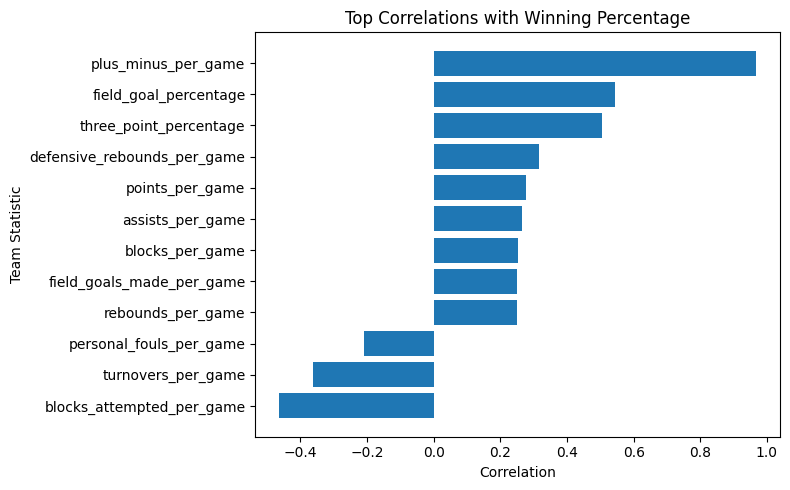

In [33]:
top_corr = corr_with_target.head(12).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top_corr.index, top_corr.values)
plt.title("Top Correlations with Winning Percentage")
plt.xlabel("Correlation")
plt.ylabel("Team Statistic")
plt.tight_layout()
plt.savefig(output_dir / "figure3_top_correlations_with_win_percentage.png", dpi=300)
plt.show()

#### visual 4: plus-minus per game and winning percentage

Plus-minus per game should be strongly related to winning percentage because it is basically a scoring-margin statistic. This makes it useful, but also a little tricky; if it dominates the model, the analysis becomes less interesting.

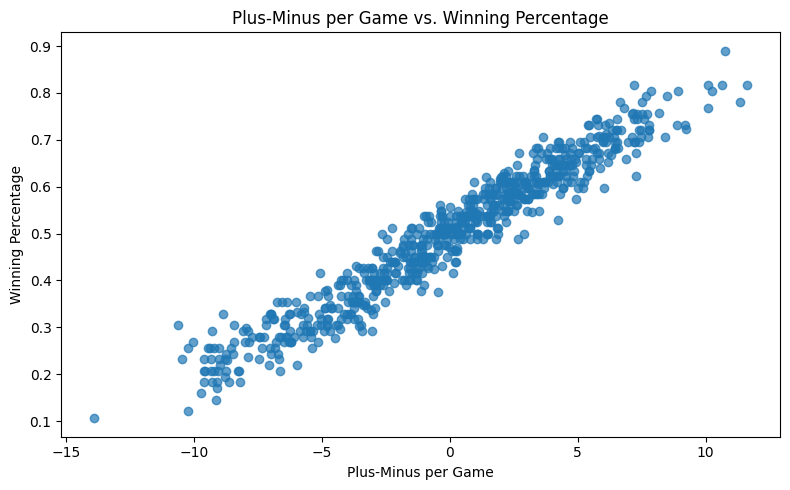

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(teams_clean["plus_minus_per_game"], teams_clean[target], alpha=0.70)
plt.title("Plus-Minus per Game vs. Winning Percentage")
plt.xlabel("Plus-Minus per Game")
plt.ylabel("Winning Percentage")
plt.tight_layout()
plt.savefig(output_dir / "figure4_plus_minus_per_game_vs_win_percentage.png", dpi=300)
plt.show()

#### prepare train and test sets

The dataset is split into training and testing data so the model can be evaluated on data it has not already seen.

In [35]:
model_data = teams_clean[feature_cols + [target]].dropna().copy()

X = model_data[feature_cols]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Rows used for modeling:", model_data.shape[0])
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Rows used for modeling: 716
Training rows: 537
Testing rows: 179


#### build models with all features

The first set of models includes all selected features, including plus-minus per game; this gives the strongest version of the model, but the interpretation has to be careful because plus-minus is so closely tied to winning.

In [16]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3
    )
}

all_feature_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    all_feature_results.append({
        "Feature Set": "All Features",
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

all_feature_results = pd.DataFrame(all_feature_results)
display(all_feature_results.sort_values("RMSE"))

,Feature Set,Model,MAE,RMSE,R2
2,All Features,Random Forest,0.029285,0.036950,0.932932
0,All Features,Linear Regression,0.029459,0.037852,0.929618
1,All Features,Ridge Regression,0.029533,0.037867,0.929561


#### build models without plus-minus

This second model set removes plus-minus per game; this is probably the more honest comparison because it tests whether the other team stats still explain winning percentage without relying on scoring margin.

In [36]:
feature_cols_no_pm = [col for col in feature_cols if col != "plus_minus_per_game"]

X_no_pm = model_data[feature_cols_no_pm]
y_no_pm = model_data[target]

X_train_no_pm, X_test_no_pm, y_train_no_pm, y_test_no_pm = train_test_split(
    X_no_pm,
    y_no_pm,
    test_size=0.25,
    random_state=42
)

no_pm_results = []

for name, model in models.items():
    model.fit(X_train_no_pm, y_train_no_pm)
    predictions = model.predict(X_test_no_pm)

    mae = mean_absolute_error(y_test_no_pm, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_no_pm, predictions))
    r2 = r2_score(y_test_no_pm, predictions)

    no_pm_results.append({
        "Feature Set": "Without Plus-Minus",
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

no_pm_results = pd.DataFrame(no_pm_results)

model_results = pd.concat([all_feature_results, no_pm_results], ignore_index=True)
model_results = model_results.sort_values(["Feature Set", "RMSE"])

display(model_results)
model_results.to_csv(output_dir / "model_results_comparison.csv", index=False)

,Feature Set,Model,MAE,RMSE,R2
2,All Features,Random Forest,0.029285,0.036950,0.932932
0,All Features,Linear Regression,0.029459,0.037852,0.929618
1,All Features,Ridge Regression,0.029533,0.037867,0.929561
4,Without Plus-Minus,Ridge Regression,0.049666,0.062788,0.806341
3,Without Plus-Minus,Linear Regression,0.049670,0.062814,0.806179
5,Without Plus-Minus,Random Forest,0.074132,0.090417,0.598404


#### visual 5: model comparison

This chart compares model RMSE across the different model and feature-set combinations. Lower RMSE means the predictions were closer to the actual winning percentages.

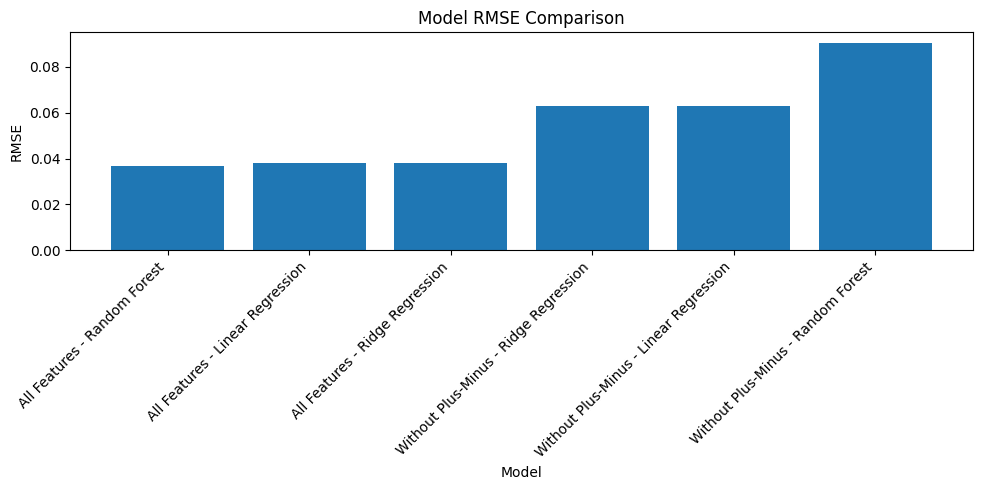

In [37]:
plot_results = model_results.copy()
plot_results["Label"] = plot_results["Feature Set"] + " - " + plot_results["Model"]

plt.figure(figsize=(10, 5))
plt.bar(plot_results["Label"], plot_results["RMSE"])
plt.title("Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "figure5_model_rmse_comparison.png", dpi=300)
plt.show()

#### select final model

The final model is selected using the lowest RMSE - this is not the only way to pick a model, but it is a clear and simple evaluation rule for this milestone.

In [38]:
best_result = model_results.sort_values("RMSE").iloc[0]

print("Best model setup:")
display(best_result)

best_feature_set = best_result["Feature Set"]
best_model_name = best_result["Model"]

if best_feature_set == "All Features":
    final_features = feature_cols
    final_X_train = X_train
    final_X_test = X_test
    final_y_train = y_train
    final_y_test = y_test
else:
    final_features = feature_cols_no_pm
    final_X_train = X_train_no_pm
    final_X_test = X_test_no_pm
    final_y_train = y_train_no_pm
    final_y_test = y_test_no_pm

final_model = models[best_model_name]
final_model.fit(final_X_train, final_y_train)
final_predictions = final_model.predict(final_X_test)

Best model setup:


Feature Set     All Features
Model          Random Forest
MAE                 0.029285
RMSE                 0.03695
R2                  0.932932
Name: 2, dtype: object

#### visual 6: actual vs predicted winning percentage

This chart compares actual winning percentage to predicted winning percentage; points close to the diagonal line are better predictions, while points farther away show where the model missed more.

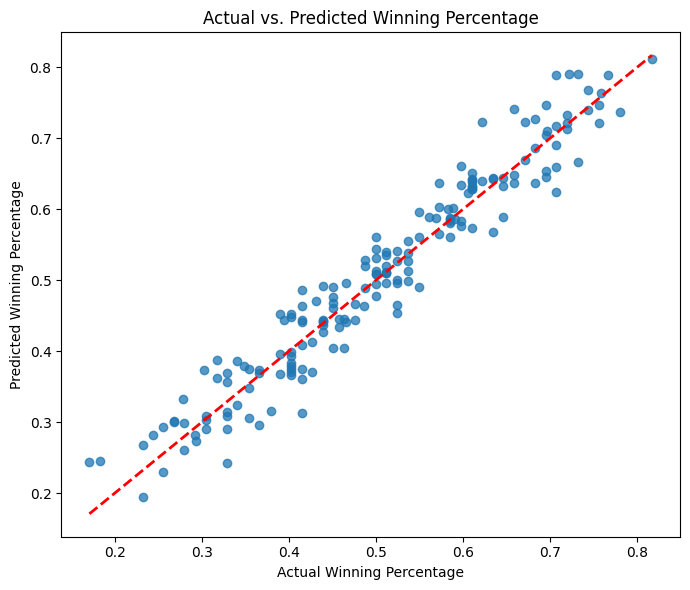

In [20]:
min_axis = min(final_y_test.min(), final_predictions.min())
max_axis = max(final_y_test.max(), final_predictions.max())

plt.figure(figsize=(7, 6))
plt.scatter(final_y_test, final_predictions, alpha=0.75)
plt.plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", color="red", linewidth=2)
plt.title("Actual vs. Predicted Winning Percentage")
plt.xlabel("Actual Winning Percentage")
plt.ylabel("Predicted Winning Percentage")
plt.tight_layout()
plt.savefig(output_dir / "figure6_actual_vs_predicted_win_percentage.png", dpi=300)
plt.show()

#### random forest feature importance

The random forest model can provide a rough feature-importance view - this should not be treated as a perfect explanation, but it can help show which variables the model leaned on most.

,Feature,Importance
20,plus_minus_per_game,0.959369
15,steals_per_game,0.003415
17,blocks_attempted_per_game,0.002865
18,personal_fouls_per_game,0.002834
1,three_point_percentage,0.002461
11,defensive_rebounds_per_game,0.002373
16,blocks_per_game,0.002225
10,offensive_rebounds_per_game,0.002161
12,rebounds_per_game,0.002155
13,assists_per_game,0.002085


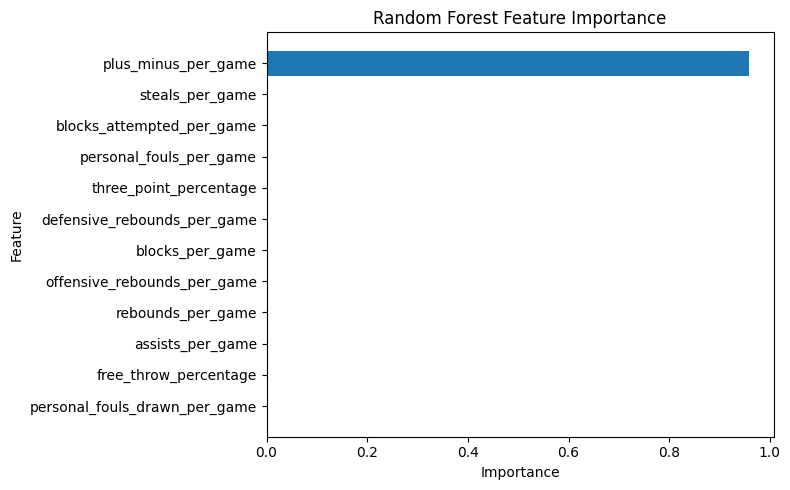

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(final_X_train[final_features], final_y_train)

importance_df = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

top_importance = importance_df.head(12).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(output_dir / "figure7_random_forest_feature_importance.png", dpi=300)
plt.show()